# Brain MRI Segmentation Using Multi-Atlas-Based Methods

### **Mounting Google Drive**

In [1]:
#Mounting my drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### **Defining Elastix Path**

In [2]:
elastix_path = "/content/drive/My Drive/Colab Notebooks/MISA/Elastix/elastix"


### **Downloading and Extracting Elastix**

In [3]:
# Define the target directory for Elastix and Transformix
ELASTIX_DIR="/content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/Elastix"

# Create the directory if it doesn't exist
!mkdir -p "$ELASTIX_DIR"

# Download Elastix
!wget https://github.com/SuperElastix/elastix/releases/download/5.0.1/elastix-5.0.1-linux.tar.bz2 -P "$ELASTIX_DIR"

# Extract Elastix into the target directory
!tar -xjf "$ELASTIX_DIR/elastix-5.0.1-linux.tar.bz2" -C "$ELASTIX_DIR"


--2026-01-09 00:04:14--  https://github.com/SuperElastix/elastix/releases/download/5.0.1/elastix-5.0.1-linux.tar.bz2
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/91586944/797fe980-03fc-11eb-9791-f8725818dfd2?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-01-09T00%3A46%3A26Z&rscd=attachment%3B+filename%3Delastix-5.0.1-linux.tar.bz2&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-01-08T23%3A46%3A16Z&ske=2026-01-09T00%3A46%3A26Z&sks=b&skv=2018-11-09&sig=aGZ3I%2FpturCE%2F1zfSCLxDqlAMdd2Fh5HM8zCl2KVZQc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2NzkxODg1NCwibmJmIjoxNzY3OTE3MDU0LCJwYXRoIjoicmVsZWF

### **Setting `LD_LIBRARY_PATH` for Elastix**

In [4]:
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/content/drive/My\ Drive/Colab\ Notebooks/MAIA\ M2/MISA/MISA_Final_Project/Elastix/elastix-5.0.1-linux/lib


### **Verifying Elastix Installation**

In [5]:
import os
import subprocess

# Define paths
elastix_path = "/content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/Elastix/elastix-5.0.1-linux/bin/elastix"
elastix_lib_path = "/content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/Elastix/elastix-5.0.1-linux/lib"

# Update LD_LIBRARY_PATH
os.environ["LD_LIBRARY_PATH"] = os.environ.get("LD_LIBRARY_PATH", "") + f":{elastix_lib_path}"

# Verify Elastix installation
try:
    result = subprocess.run([elastix_path, "--help"], check=True, capture_output=True, text=True)
    print("Elastix is working correctly.")
    print(result.stdout)
except subprocess.CalledProcessError as e:
    print("Elastix help command failed.")
    print(e.stderr)


Elastix is working correctly.
elastix version: 5.0.1

elastix registers a moving image to a fixed image.
The registration-process is specified in the parameter file.
  --help, -h displays this message and exit
  --version  output version information and exit
  --extended-version  output extended version information and exit

Call elastix from the command line with mandatory arguments:
  -f        fixed image
  -m        moving image
  -out      output directory
  -p        parameter file, elastix handles 1 or more "-p"

Optional extra commands:
  -fMask    mask for fixed image
  -mMask    mask for moving image
  -t0       parameter file for initial transform
  -priority set the process priority to high, abovenormal, normal (default),
            belownormal, or idle (Windows only option)
  -threads  set the maximum number of threads of elastix

The parameter-file must contain all the information necessary for elastix to run properly. That includes which metric to use, which optimizer, 

### **Re-exporting `LD_LIBRARY_PATH`**

In [6]:
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/content/drive/My\ Drive/Colab\ Notebooks/MAIA\ M2/MISA/MISA_Final_Project/Elastix/elastix-5.0.1-linux/lib


### **Installing SimpleITK**

In [7]:
!pip install SimpleITK


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 20.7 MB/s eta 0:00:00


### **Importing Libraries**

In [8]:
# General utilities
import shutil
import subprocess
import time
import json

# Numeric and image processing libraries
import numpy as np
import nibabel as nib
import SimpleITK as sitk
from scipy.ndimage import median_filter
from scipy.stats import mode, norm
from skimage import exposure

# Visualization
import matplotlib.pyplot as plt


### **`visualize_segmentation_results` Function**

In [9]:
def visualize_segmentation_results(ground_truth, segmentation_result, title_suffix, method_name):
    """
    Display validation image segmentation results alongside its ground truth.

    Args:
        ground_truth (np.ndarray): The ground truth segmentation.
        segmentation_result (np.ndarray): The result of the segmentation method.
        title_suffix (str): The suffix for figure titles.
        method_name (str): The name of the segmentation method (e.g., "Majority Voting (MV)", "Non-Local", etc.).
    """
    middle_slice = ground_truth.shape[2] // 2
    ground_truth_slice = np.rot90(ground_truth[:, :, middle_slice])
    segmentation_result_slice = np.rot90(segmentation_result[:, :, middle_slice])

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.imshow(ground_truth_slice, cmap="gray")
    plt.title(f"Ground Truth ({title_suffix})", fontsize=12)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(segmentation_result_slice, cmap="gray")
    plt.title(f"{method_name} Result ({title_suffix})", fontsize=12)
    plt.axis("off")
    plt.tight_layout(pad=2.0)
    plt.show()


### **`dice_coefficient` Function**

In [10]:
def dice_coefficient(seg, gt):
    intersection = np.sum((seg > 0) & (gt > 0))
    sum_seg_gt = np.sum(seg > 0) + np.sum(gt > 0)
    return 2.0 * intersection / sum_seg_gt if sum_seg_gt > 0 else 0.0

### **`load_nifti_image` Function**

In [11]:
def load_nifti_image(image_path):
    try:
        nifti_image = nib.load(image_path)
        image_data = nifti_image.get_fdata()  # Convert to NumPy array
        return image_data
    except Exception as e:
        raise ValueError(f"Error loading NIfTI image from {image_path}: {e}")

### **Defining Directory Paths and Configuration Parameters**

In [12]:
# Base directory for the project
base_dir = "/content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets"

# Input directories
training_dir = os.path.join(base_dir, "Training_Set")
validation_dir = os.path.join(base_dir, "Validation_Set")

# Registration and transformed labels directories
registration_results_dir = os.path.join(base_dir, "Registration_Results")
transformed_labels_dir = os.path.join(base_dir, "Transformed_Labels")

# Segmentation results directories
majority_voting_dir = os.path.join(base_dir, "Majority_Voting")
weighted_majority_voting_dir = os.path.join(base_dir, "Weighted_Majority_Voting")
# Non-local segmentation directories
non_local_segmentation_dir = os.path.join(base_dir, "Non_Local_Segmentation")
non_local_similar_patch_dir = os.path.join(base_dir, "Non_Local_Segmentation_with_SimilarPatch")
non_local_similar_patch_dir_large_patch = os.path.join(base_dir, "Non_Local_Segmentation_with_SimilarPatch_large_patch")
em_results_dir = os.path.join(base_dir, "EM_Results_MV")
em_results_wmv_dir = os.path.join(base_dir, "EM_Results_WMV")
em_results_non_local_dir = os.path.join(base_dir, "EM_Results_NonLocal_means")


# Similarity weights and voxel-wise directories
similarity_weights_file = os.path.join(base_dir, "Similarity_weight.json")
voxelwise_weights_dir = os.path.join(base_dir, "VoxelWise_Similarity_Weights")
voxelwise_wmv_dir = os.path.join(base_dir, "Voxel_wise_Weighted_Majority_Voting")

# Ground truth directory
validation_ground_truth_dir = validation_dir

# Elastix and Transformix parameter files
parameter_file_affine = "/content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/Parameters.Par0009.affine.txt"
parameter_file_b_spline = "/content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/Parameters.Par0009.elastic.txt"

# Elastix and Transformix executable paths
elastix_path = "/content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/Elastix/elastix-5.0.1-linux/bin/elastix"
transformix_path = "/content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/Elastix/elastix-5.0.1-linux/bin/transformix"
elastix_lib_path = "/content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/Elastix/elastix-5.0.1-linux/lib"

# Ensure output directories exist
os.makedirs(majority_voting_dir, exist_ok=True)
os.makedirs(weighted_majority_voting_dir, exist_ok=True)
os.makedirs(em_results_dir, exist_ok=True)
os.makedirs(em_results_wmv_dir, exist_ok=True)
os.makedirs(em_results_non_local_dir, exist_ok=True)
os.makedirs(voxelwise_weights_dir, exist_ok=True)
os.makedirs(voxelwise_wmv_dir, exist_ok=True)
os.makedirs(non_local_segmentation_dir, exist_ok=True)
os.makedirs(non_local_similar_patch_dir, exist_ok=True)
os.makedirs(non_local_similar_patch_dir_large_patch, exist_ok=True)


### **Image Registration for Validation and Training Datasets Using Elastix**

In [13]:
# Updating LD_LIBRARY_PATH dynamically
os.environ["LD_LIBRARY_PATH"] = os.environ.get("LD_LIBRARY_PATH", "") + f":{elastix_lib_path}"

# Creating temporary and base output directories if they don't exist
temp_output_dir = "/content/output"
os.makedirs(temp_output_dir, exist_ok=True)
os.makedirs(registration_results_dir, exist_ok=True)

# Iterate through validation subfolders (fixed images)
for val_subfolder in sorted(os.listdir(validation_dir)):
    val_path = os.path.join(validation_dir, val_subfolder)
    if os.path.isdir(val_path):
        val_image = os.path.join(val_path, f"{val_subfolder}.nii.gz")
        val_output_group_dir = os.path.join(registration_results_dir, val_subfolder)
        os.makedirs(val_output_group_dir, exist_ok=True)

        # Iterate through training subfolders (moving images)
        for train_subfolder in sorted(os.listdir(training_dir)):
            train_path = os.path.join(training_dir, train_subfolder)
            if os.path.isdir(train_path):
                train_image = os.path.join(train_path, f"{train_subfolder}.nii.gz")
                pair_output_dir = os.path.join(val_output_group_dir, f"{train_subfolder}")
                os.makedirs(pair_output_dir, exist_ok=True)

                # Elastix command for affine and B-spline registration
                elastix_command = [
                    elastix_path,
                    "-f", val_image,
                    "-m", train_image,
                    "-out", temp_output_dir,
                    "-p", parameter_file_affine,
                    "-p", parameter_file_b_spline
                ]

                # Run Elastix
                try:
                    print(f"Registering {train_subfolder} (moving) to {val_subfolder} (fixed)...")
                    start_time = time.time()
                    subprocess.run(elastix_command, check=True, capture_output=True, text=True)
                    elapsed_time = time.time() - start_time
                    print(f"Registration complete: {train_subfolder} -> {val_subfolder} in {elapsed_time:.2f} seconds.")

                    # Move and update result files
                    for filename in os.listdir(temp_output_dir):
                        temp_file_path = os.path.join(temp_output_dir, filename)

                        # Rename result files
                        if filename.startswith("result.0"):
                            new_name = f"{val_subfolder}_to_{train_subfolder}_affine.nii"
                        elif filename.startswith("result.1"):
                            new_name = f"{val_subfolder}_to_{train_subfolder}_bspline.nii"
                        elif filename.startswith("TransformParameters.1"):
                            new_name = "TransformParameters.1.txt"
                        elif filename.startswith("TransformParameters.0"):
                            new_name = "TransformParameters.0.txt"
                        else:
                            new_name = filename  # Keep original name for other files

                        perm_file_path = os.path.join(pair_output_dir, new_name)
                        shutil.move(temp_file_path, perm_file_path)

                    # Update the path in TransformParameters.1.txt
                    transform_parameters_1 = os.path.join(pair_output_dir, "TransformParameters.1.txt")
                    transform_parameters_0 = os.path.join(pair_output_dir, "TransformParameters.0.txt")

                    if os.path.exists(transform_parameters_1):
                        with open(transform_parameters_1, "r") as file:
                            content = file.read()

                        # Replace the temporary path with the permanent path
                        updated_content = content.replace(
                            os.path.join(temp_output_dir, "TransformParameters.0.txt"),
                            transform_parameters_0
                        )

                        # Writing the updated content back to the file
                        with open(transform_parameters_1, "w") as file:
                            file.write(updated_content)

                    print(f"Results moved and updated for {train_subfolder} -> {val_subfolder}")

                except subprocess.CalledProcessError as e:
                    print(f"Registration failed: {train_subfolder} -> {val_subfolder}")
                    print(e.stderr)

                finally:
                    # Clear temporary output directory contents after processing
                    for temp_file in os.listdir(temp_output_dir):
                        temp_file_path = os.path.join(temp_output_dir, temp_file)
                        os.remove(temp_file_path)


Registering IBSR_01 (moving) to IBSR_11 (fixed)...
Registration complete: IBSR_01 -> IBSR_11 in 126.36 seconds.
Results moved and updated for IBSR_01 -> IBSR_11
Registering IBSR_03 (moving) to IBSR_11 (fixed)...
Registration complete: IBSR_03 -> IBSR_11 in 119.63 seconds.
Results moved and updated for IBSR_03 -> IBSR_11
Registering IBSR_04 (moving) to IBSR_11 (fixed)...
Registration complete: IBSR_04 -> IBSR_11 in 111.92 seconds.
Results moved and updated for IBSR_04 -> IBSR_11
Registering IBSR_05 (moving) to IBSR_11 (fixed)...
Registration complete: IBSR_05 -> IBSR_11 in 117.28 seconds.
Results moved and updated for IBSR_05 -> IBSR_11
Registering IBSR_06 (moving) to IBSR_11 (fixed)...
Registration complete: IBSR_06 -> IBSR_11 in 117.28 seconds.
Results moved and updated for IBSR_06 -> IBSR_11
Registering IBSR_07 (moving) to IBSR_11 (fixed)...
Registration complete: IBSR_07 -> IBSR_11 in 120.12 seconds.
Results moved and updated for IBSR_07 -> IBSR_11
Registering IBSR_08 (moving) to IB

### **Applying Transformix for Label Transformation**

In [14]:
os.environ["LD_LIBRARY_PATH"] = os.environ.get("LD_LIBRARY_PATH", "") + f":{elastix_lib_path}"
os.makedirs(transformed_labels_dir, exist_ok=True) # Create the base directory for transformed labels
# Iterate through validation subfolders in Registration_Results
for val_subfolder in sorted(os.listdir(registration_results_dir)):
    val_results_path = os.path.join(registration_results_dir, val_subfolder)
    if os.path.isdir(val_results_path):
        # Iterate through training subfolders
        for train_subfolder in sorted(os.listdir(val_results_path)):
            train_results_path = os.path.join(val_results_path, train_subfolder)
            if os.path.isdir(train_results_path):
                b_spline_param_file = os.path.join(train_results_path, "TransformParameters.1.txt")
                if not os.path.exists(b_spline_param_file):
                    print(f"Missing B-spline transform parameters: {b_spline_param_file}")
                    continue

                # Path to the corresponding training ground truth label
                train_label = os.path.join(training_dir, train_subfolder, f"{train_subfolder}_seg.nii.gz")
                if not os.path.exists(train_label):
                    print(f"Ground truth label missing: {train_label}")
                    continue

                # Create a subfolder in Transformed_Labels for this training image
                train_transformed_dir = os.path.join(transformed_labels_dir, val_subfolder, train_subfolder)
                os.makedirs(train_transformed_dir, exist_ok=True)
                # Temporary output directory for Transformix results
                temp_output_dir = "/content/output"
                os.makedirs(temp_output_dir, exist_ok=True)

                # Transformix command
                transformix_command = [
                    transformix_path,
                    "-in", train_label,  # Input training ground truth label
                    "-out", temp_output_dir,  # Temporary output directory for results
                    "-tp", b_spline_param_file  # Transformation parameter file
                ]
                # Run Transformix
                try:
                    print(f"Applying transformix on {train_subfolder} ground truth using {val_subfolder} parameters...")
                    start_time = time.time()  # Start time
                    subprocess.run(transformix_command, check=True, capture_output=True, text=True)
                    end_time = time.time()  # End time
                    elapsed_time = end_time - start_time
                    print(f"Transformation complete for {train_subfolder} (Time taken: {elapsed_time:.2f} seconds)")

                    # Move the transformed label to the training-specific directory
                    for filename in os.listdir(temp_output_dir):
                        temp_file_path = os.path.join(temp_output_dir, filename)

                        # Rename the transformed ground truth file
                        if filename == "result.nii.gz":
                            new_name = f"{train_subfolder}_seg_transformed.nii"
                        else:
                            new_name = filename  # Keep original name for other files

                        permanent_file_path = os.path.join(train_transformed_dir, new_name)
                        shutil.move(temp_file_path, permanent_file_path)

                    print(f"Transformed label moved to: {train_transformed_dir}")
                except subprocess.CalledProcessError as e:
                    print(f"Transformix failed for {train_subfolder} using {val_subfolder}")
                    print(e.stderr)
                finally:
                    # Clear the temporary directory contents
                    for temp_file in os.listdir(temp_output_dir):
                        temp_file_path = os.path.join(temp_output_dir, temp_file)
                        os.remove(temp_file_path)


Missing B-spline transform parameters: /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Registration_Results/IBSR_11/.DS_Store/TransformParameters.1.txt
Applying transformix on IBSR_01 ground truth using IBSR_11 parameters...
Transformation complete for IBSR_01 (Time taken: 22.48 seconds)
Transformed label moved to: /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Transformed_Labels/IBSR_11/IBSR_01
Applying transformix on IBSR_03 ground truth using IBSR_11 parameters...
Transformation complete for IBSR_03 (Time taken: 19.97 seconds)
Transformed label moved to: /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Transformed_Labels/IBSR_11/IBSR_03
Applying transformix on IBSR_04 ground truth using IBSR_11 parameters...
Transformation complete for IBSR_04 (Time taken: 19.71 seconds)
Transformed label moved to: /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Pr

### **Performing Majority Voting**

In [15]:
# Initialize variables for average DSC calculation
total_dice_csf = 0.0
total_dice_gm = 0.0
total_dice_wm = 0.0
count = 0

# Iterate through transformed labels subfolders (one per validation image)
for val_subfolder in os.listdir(transformed_labels_dir):
    val_transformed_path = os.path.join(transformed_labels_dir, val_subfolder)
    if os.path.isdir(val_transformed_path):
        # Collect all transformed labels from training subfolders
        transformed_label_files = []
        for train_subfolder in os.listdir(val_transformed_path):
            train_subfolder_path = os.path.join(val_transformed_path, train_subfolder)
            if os.path.isdir(train_subfolder_path):
                result_file = os.path.join(train_subfolder_path, "result.nii")
                if os.path.exists(result_file):
                    transformed_label_files.append(result_file)

        if len(transformed_label_files) == 0:
            print(f"No transformed labels found for {val_subfolder}. Skipping.")
            continue

        # Initialize a 4D volume for majority voting
        label_sample = nib.load(transformed_label_files[0])
        label_shape = label_sample.shape
        volumes_4d = np.zeros((*label_shape, len(transformed_label_files)), dtype=np.int16)

        # Load each transformed label into the 4D volume
        for idx, label_file in enumerate(transformed_label_files):
            label_data = nib.load(label_file).get_fdata()
            volumes_4d[..., idx] = label_data

        # Perform majority voting
        segmented_image = mode(volumes_4d, axis=-1)[0].squeeze()

        # Save the majority-voted segmentation result
        output_file = os.path.join(majority_voting_dir, f"{val_subfolder}_MV.nii.gz")
        nib.save(nib.Nifti1Image(segmented_image.astype(np.int16), label_sample.affine), output_file)
        print(f"Saved majority-voted segmentation for {val_subfolder} to {output_file}")

        # Load ground truth for the validation subject
        groundtruth_file = os.path.join(validation_dir, val_subfolder, f"{val_subfolder}_seg.nii.gz")
        if not os.path.exists(groundtruth_file):
            print(f"Ground truth not found for {val_subfolder}. Skipping metrics computation.")
            continue
        groundtruth_data = np.squeeze(nib.load(groundtruth_file).get_fdata())

        # Compute Dice similarity for each tissue class (CSF=1, GM=2, WM=3)
        dice_csf = dice_coefficient(segmented_image == 1, groundtruth_data == 1)
        dice_gm = dice_coefficient(segmented_image == 2, groundtruth_data == 2)
        dice_wm = dice_coefficient(segmented_image == 3, groundtruth_data == 3)
        print(f"DSC for {val_subfolder}: CSF={dice_csf:.3f}, GM={dice_gm:.3f}, WM={dice_wm:.3f}")

        # Accumulate Dice scores for average calculation
        total_dice_csf += dice_csf
        total_dice_gm += dice_gm
        total_dice_wm += dice_wm
        count += 1

        # Compute Average Volumetric Difference (AVD)
        avd = []
        for label in [1, 2, 3]:  # Iterate over tissue labels
            gt_voxels = np.sum(groundtruth_data == label)
            seg_voxels = np.sum(segmented_image == label)
            avd.append(abs(gt_voxels - seg_voxels) / gt_voxels if gt_voxels > 0 else 0)
        avg_avd = np.mean(avd)
        print(f"AVD for {val_subfolder}: {avg_avd:.3f}")

# Calculate and display average Dice scores
if count > 0:
    avg_dice_csf = total_dice_csf / count
    avg_dice_gm = total_dice_gm / count
    avg_dice_wm = total_dice_wm / count
    print(f"\nAverage DSC across all images:")
    print(f"CSF: {avg_dice_csf:.3f}, GM: {avg_dice_gm:.3f}, WM: {avg_dice_wm:.3f}")
else:
    print("No valid data to compute average DSC.")


Saved majority-voted segmentation for IBSR_11 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Majority_Voting/IBSR_11_MV.nii.gz
DSC for IBSR_11: CSF=0.833, GM=0.857, WM=0.846
AVD for IBSR_11: 0.073
Saved majority-voted segmentation for IBSR_12 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Majority_Voting/IBSR_12_MV.nii.gz
DSC for IBSR_12: CSF=0.821, GM=0.857, WM=0.848
AVD for IBSR_12: 0.103
Saved majority-voted segmentation for IBSR_13 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Majority_Voting/IBSR_13_MV.nii.gz
DSC for IBSR_13: CSF=0.796, GM=0.877, WM=0.814
AVD for IBSR_13: 0.108
Saved majority-voted segmentation for IBSR_14 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Majority_Voting/IBSR_14_MV.nii.gz
DSC for IBSR_14: CSF=0.847, GM=0.888, WM=0.849
AVD for IBSR_14: 0.052
Saved majority-voted seg

### **Visualizing Majority Voting Results**

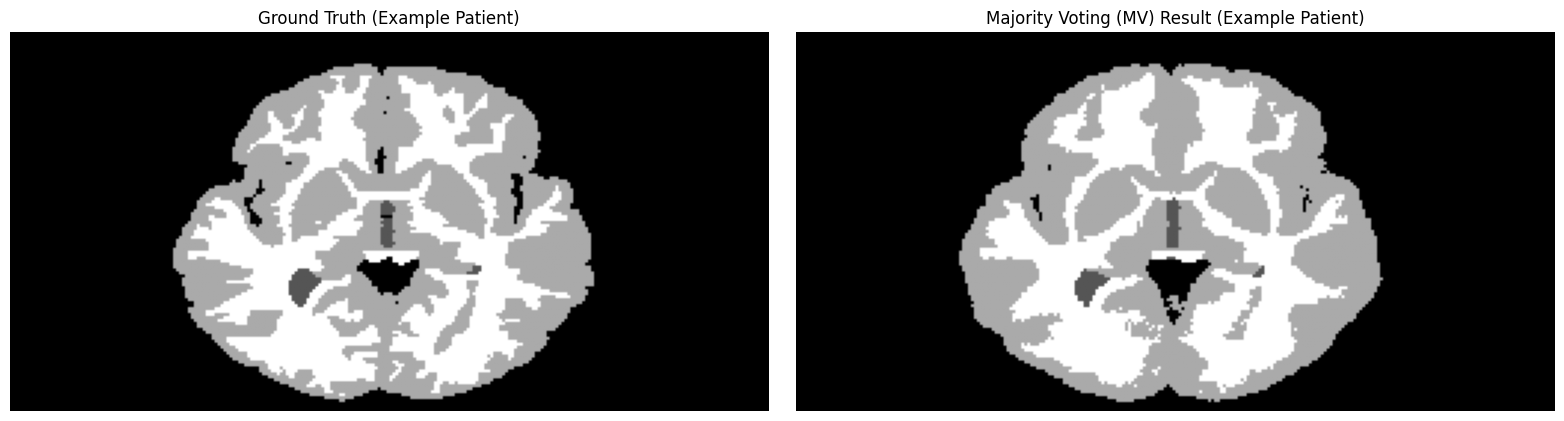

In [16]:
#  Displaying ground turth vs segmentaion result
sample_id = "IBSR_14"
ground_truth_path = os.path.join(validation_dir, sample_id, f"{sample_id}_seg.nii.gz")
segmentation_result_path = os.path.join(majority_voting_dir, f"{sample_id}_MV.nii.gz")

# Load images
ground_truth = load_nifti_image(ground_truth_path)
segmentation_result = load_nifti_image(segmentation_result_path)

# Visualize the results
visualize_segmentation_results(
    ground_truth=ground_truth,
    segmentation_result=segmentation_result,
    title_suffix="Example Patient",
    method_name="Majority Voting (MV)"
)


### **Computing NCC and Saving Weights**

In [17]:
similarity_weights = {}
# Iterate through validation subfolders (fixed images)
for val_subfolder in sorted(os.listdir(validation_dir)):
    val_path = os.path.join(validation_dir, val_subfolder)
    if os.path.isdir(val_path):
        val_image_path = os.path.join(val_path, f"{val_subfolder}.nii.gz")
        if not os.path.exists(val_image_path):
            print(f"Validation image not found: {val_image_path}")
            continue

        try:
            val_image = nib.load(val_image_path).get_fdata().astype(np.float64)
            val_image = np.squeeze(val_image)
            val_image = (val_image - np.mean(val_image)) / np.std(val_image)  # Normalize
            print(f"Validation image {val_subfolder} loaded with shape {val_image.shape}")

            similarity_weights[val_subfolder] = []

            # Iterate through corresponding training results
            train_results_path = os.path.join(registration_results_dir, val_subfolder)
            if os.path.isdir(train_results_path):
                for train_subfolder in sorted(os.listdir(train_results_path)):
                    registered_image_path = os.path.join(
                        train_results_path,
                        train_subfolder,
                        f"{val_subfolder}_to_{train_subfolder}_bspline.nii"
                    )
                    if not os.path.exists(registered_image_path):
                        print(f"Registered image not found: {registered_image_path}")
                        similarity_weights[val_subfolder].append(0)
                        continue

                    try:
                        registered_image = nib.load(registered_image_path).get_fdata().astype(np.float64)
                        registered_image = (registered_image - np.mean(registered_image)) / np.std(registered_image)

                        ncc_values = []
                        for k in range(val_image.shape[2]):
                            val_slice = val_image[:, :, k]
                            reg_slice = registered_image[:, :, k]
                            if np.std(val_slice) == 0 or np.std(reg_slice) == 0:
                                ncc = 0
                            else:
                                numerator = np.sum((val_slice - np.mean(val_slice)) * (reg_slice - np.mean(reg_slice)))
                                denominator = np.sqrt(np.sum((val_slice - np.mean(val_slice))**2)) * \
                                              np.sqrt(np.sum((reg_slice - np.mean(reg_slice))**2))
                                ncc = numerator / denominator if denominator != 0 else 0
                            ncc_values.append(ncc)

                        avg_ncc = np.mean(ncc_values)
                        similarity_weights[val_subfolder].append(avg_ncc)
                        print(f"NCC for {val_subfolder} -> {train_subfolder}: {abs(avg_ncc):.3f}")
                    except Exception as e:
                        print(f"Error processing {registered_image_path}: {e}")
                        similarity_weights[val_subfolder].append(0)
        except Exception as e:
            print(f"Error loading validation image {val_image_path}: {e}")

# Normalize all similarity weights globally
all_weights = [w for weights in similarity_weights.values() for w in weights]
global_min = min(all_weights)
global_max = max(all_weights)

for val_subfolder, weights in similarity_weights.items():
    similarity_weights[val_subfolder] = [
        (w - global_min) / (global_max - global_min) if global_max > global_min else 0 for w in weights
    ]

# Save normalized weights to JSON
os.makedirs(os.path.dirname(similarity_weights_file), exist_ok=True)
with open(similarity_weights_file, "w") as f:
    json.dump(similarity_weights, f)
print(f"Normalized similarity weights saved to {similarity_weights_file}")


Validation image IBSR_11 loaded with shape (256, 128, 256)
NCC for IBSR_11 -> IBSR_01: 0.001
NCC for IBSR_11 -> IBSR_03: 0.955
NCC for IBSR_11 -> IBSR_04: 0.002
NCC for IBSR_11 -> IBSR_05: 0.012
NCC for IBSR_11 -> IBSR_06: 0.471
NCC for IBSR_11 -> IBSR_07: 0.004
NCC for IBSR_11 -> IBSR_08: 0.476
NCC for IBSR_11 -> IBSR_09: 0.959
NCC for IBSR_11 -> IBSR_16: 0.468
NCC for IBSR_11 -> IBSR_18: 0.468
Validation image IBSR_12 loaded with shape (256, 128, 256)
NCC for IBSR_12 -> IBSR_01: 0.021
NCC for IBSR_12 -> IBSR_03: 0.938
NCC for IBSR_12 -> IBSR_04: 0.008
NCC for IBSR_12 -> IBSR_05: 0.005
NCC for IBSR_12 -> IBSR_06: 0.021
NCC for IBSR_12 -> IBSR_07: 0.946
NCC for IBSR_12 -> IBSR_08: 0.955
NCC for IBSR_12 -> IBSR_09: 0.023
NCC for IBSR_12 -> IBSR_16: 0.005
NCC for IBSR_12 -> IBSR_18: 0.938
Validation image IBSR_13 loaded with shape (256, 128, 256)
NCC for IBSR_13 -> IBSR_01: 0.508
NCC for IBSR_13 -> IBSR_03: 0.056
NCC for IBSR_13 -> IBSR_04: 0.959
NCC for IBSR_13 -> IBSR_05: 0.964
NCC for

### **Performing Weighted Majority Voting**

In [18]:
# Initialize accumulators for Dice scores
total_dice_csf, total_dice_gm, total_dice_wm = 0.0, 0.0, 0.0
subject_count = 0

# Load similarity weights
similarity_weights_path = os.path.join(base_dir, "Similarity_weight.json")
with open(similarity_weights_path, "r") as f:
    similarity_weights = json.load(f)

# Debugging: Print the loaded weights
print(f"Loaded similarity weights for subjects: {list(similarity_weights.keys())}")

# Iterate through transformed labels subfolders
for val_subfolder in os.listdir(transformed_labels_dir):
    val_transformed_path = os.path.join(transformed_labels_dir, val_subfolder)
    if os.path.isdir(val_transformed_path):
        if val_subfolder not in similarity_weights:
            print(f"Validation subject {val_subfolder} not found in similarity weights. Skipping.")
            continue

        # Get similarity weights for the current validation subject
        weights = similarity_weights[val_subfolder]

        # Collect transformed label paths
        transformed_label_paths = []
        for train_subfolder in sorted(os.listdir(val_transformed_path)):
            train_path = os.path.join(val_transformed_path, train_subfolder)
            label_file = os.path.join(train_path, "result.nii")
            if os.path.exists(label_file):
                transformed_label_paths.append(label_file)

        if len(transformed_label_paths) != len(weights):
            print(f"Mismatch: {len(transformed_label_paths)} labels found but {len(weights)} weights for {val_subfolder}. Skipping.")
            continue

        # Initialize a 4D volume for propagated labels
        label_sample = nib.load(transformed_label_paths[0])
        label_shape = label_sample.shape
        volumes_4d = np.zeros((*label_shape, len(transformed_label_paths)), dtype=np.int16)

        # Load each transformed label into the 4D volume
        for idx, label_path in enumerate(transformed_label_paths):
            label_data = nib.load(label_path).get_fdata().astype(np.int16)
            volumes_4d[..., idx] = label_data

        # Initialize the final segmentation array
        final_labels = np.zeros(label_shape, dtype=np.int16)

        # Perform weighted majority voting for each voxel
        for a in range(label_shape[0]):
            for b in range(label_shape[1]):
                for c in range(label_shape[2]):
                    # Compute weighted votes for each label
                    vote_count = np.zeros(4)  # Assuming 4 classes: 0 (BG), 1 (CSF), 2 (GM), 3 (WM)
                    for m in range(len(transformed_label_paths)):
                        label = int(volumes_4d[a, b, c, m])
                        vote_count[label] += weights[m]

                    # Assign label with the highest weighted vote
                    final_labels[a, b, c] = np.argmax(vote_count)

        # Apply a median filter to remove isolated misclassifications
        final_labels = median_filter(final_labels, size=3)  # Apply 3x3x3 median filter

        # Save weighted majority-voted segmentation result
        output_file = os.path.join(weighted_majority_voting_dir, f"{val_subfolder}_WMV.nii.gz")
        nib.save(nib.Nifti1Image(final_labels, label_sample.affine), output_file)
        print(f"Saved WMV segmentation for {val_subfolder} to {output_file}")

        # Load ground truth for the validation subject
        groundtruth_file = os.path.join(validation_dir, val_subfolder, f"{val_subfolder}_seg.nii.gz")
        if not os.path.exists(groundtruth_file):
            print(f"Ground truth not found for {val_subfolder}. Skipping metrics computation.")
            continue
        groundtruth_data = np.squeeze(nib.load(groundtruth_file).get_fdata().astype(np.int16))

        # Compute Dice similarity for each tissue class (CSF=1, GM=2, WM=3)
        dice_csf = dice_coefficient(final_labels == 1, groundtruth_data == 1)
        dice_gm = dice_coefficient(final_labels == 2, groundtruth_data == 2)
        dice_wm = dice_coefficient(final_labels == 3, groundtruth_data == 3)
        print(f"DSC for {val_subfolder}: CSF={dice_csf:.3f}, GM={dice_gm:.3f}, WM={dice_wm:.3f}")

        # Accumulate Dice scores for averaging
        total_dice_csf += dice_csf
        total_dice_gm += dice_gm
        total_dice_wm += dice_wm
        subject_count += 1

        # Compute Average Volumetric Difference (AVD)
        avd = []
        for label in [1, 2, 3]:  # Iterate over tissue labels
            gt_voxels = np.sum(groundtruth_data == label)
            seg_voxels = np.sum(final_labels == label)
            avd.append(abs(gt_voxels - seg_voxels) / gt_voxels if gt_voxels > 0 else 0)
        avg_avd = np.mean(avd)
        print(f"AVD for {val_subfolder}: {avg_avd:.3f}")

# Compute and display average Dice scores across all validation subjects
if subject_count > 0:
    avg_dice_csf = total_dice_csf / subject_count
    avg_dice_gm = total_dice_gm / subject_count
    avg_dice_wm = total_dice_wm / subject_count

    print("\nAverage Dice Scores Across All Subjects:")
    print(f"CSF: {avg_dice_csf:.3f}, GM: {avg_dice_gm:.3f}, WM: {avg_dice_wm:.3f}")
else:
    print("No subjects processed. Average Dice scores cannot be computed.")


Loaded similarity weights for subjects: ['IBSR_11', 'IBSR_12', 'IBSR_13', 'IBSR_14', 'IBSR_17']
Saved WMV segmentation for IBSR_11 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Weighted_Majority_Voting/IBSR_11_WMV.nii.gz
DSC for IBSR_11: CSF=0.813, GM=0.850, WM=0.844
AVD for IBSR_11: 0.101
Saved WMV segmentation for IBSR_12 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Weighted_Majority_Voting/IBSR_12_WMV.nii.gz
DSC for IBSR_12: CSF=0.787, GM=0.847, WM=0.844
AVD for IBSR_12: 0.146
Saved WMV segmentation for IBSR_13 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Weighted_Majority_Voting/IBSR_13_WMV.nii.gz
DSC for IBSR_13: CSF=0.772, GM=0.866, WM=0.800
AVD for IBSR_13: 0.137
Saved WMV segmentation for IBSR_14 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Weighted_Majority_Voting/IBSR_14_WMV.nii.gz
DS

### **Visualizing Weighted Majority Voting Results**

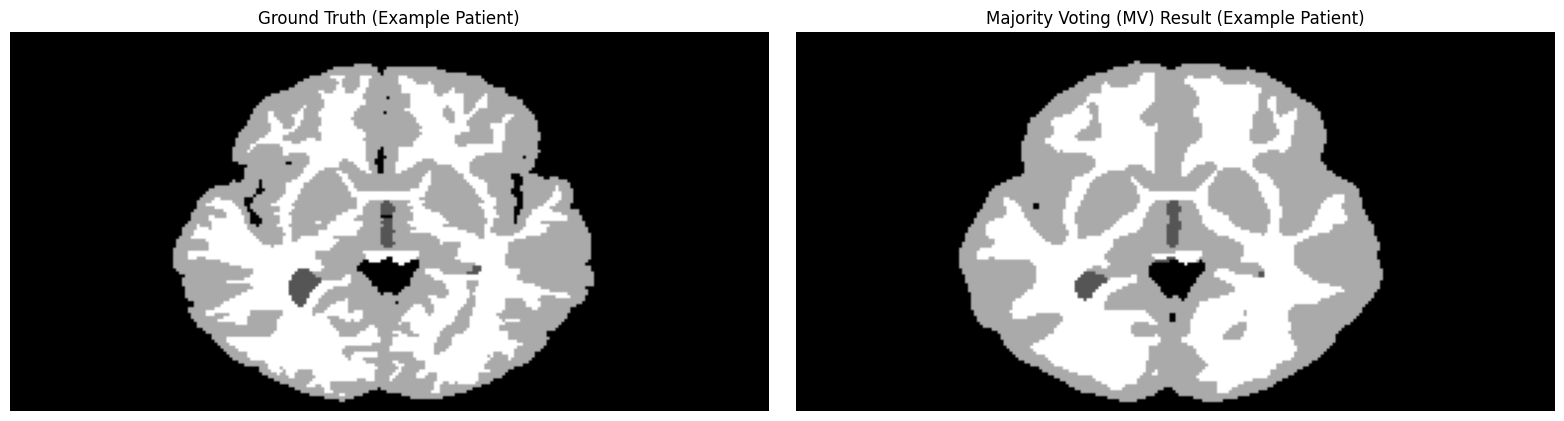

In [19]:
# #  Displaying ground turth vs segmentaion result
sample_id = "IBSR_14"
ground_truth_path = os.path.join(validation_dir, sample_id, f"{sample_id}_seg.nii.gz")
segmentation_result_path = os.path.join(weighted_majority_voting_dir, f"{sample_id}_WMV.nii.gz")

# Load images
ground_truth = load_nifti_image(ground_truth_path)
segmentation_result = load_nifti_image(segmentation_result_path)

# Visualize the results
visualize_segmentation_results(
    ground_truth=ground_truth,
    segmentation_result=segmentation_result,
    title_suffix="Example Patient",
    method_name="Majority Voting (MV)"
)


### **Performing Voxel-wise Weighted Majority Voting**

In [31]:
# Initialize variables to calculate average Dice scores
dice_scores = {"CSF": [], "GM": [], "WM": []}
avd_scores = []

# Iterate through transformed labels subfolders
for val_subfolder in os.listdir(transformed_labels_dir):
    val_transformed_path = os.path.join(transformed_labels_dir, val_subfolder)
    if os.path.isdir(val_transformed_path):
        print(f"Processing {val_subfolder}...")

        # Collect transformed label paths and NCC maps
        transformed_label_paths = []
        ncc_map_paths = []
        for train_subfolder in sorted(os.listdir(val_transformed_path)):
            train_path = os.path.join(val_transformed_path, train_subfolder)
            label_file = os.path.join(train_path, "result.nii")
            ncc_map_file = os.path.join(voxelwise_weights_dir, f"{val_subfolder}_to_{train_subfolder}_ncc_map.nii.gz")
            if os.path.exists(label_file) and os.path.exists(ncc_map_file):
                transformed_label_paths.append(label_file)
                ncc_map_paths.append(ncc_map_file)

        if len(transformed_label_paths) == 0:
            print(f"No valid transformed labels or NCC maps for {val_subfolder}. Skipping.")
            continue

        # Initialize 4D volumes for labels and weights
        label_sample = nib.load(transformed_label_paths[0])
        label_shape = label_sample.shape
        volumes_4d = np.zeros((*label_shape, len(transformed_label_paths)), dtype=np.int16)
        voxel_weights = np.zeros((*label_shape, len(transformed_label_paths)), dtype=np.float32)

        # Load labels and weights
        for idx, (label_path, ncc_map_path) in enumerate(zip(transformed_label_paths, ncc_map_paths)):
            label_data = nib.load(label_path).get_fdata().astype(np.int16)
            ncc_map = nib.load(ncc_map_path).get_fdata().astype(np.float32)
            volumes_4d[..., idx] = label_data
            voxel_weights[..., idx] = ncc_map

        # Initialize final segmentation
        final_labels = np.zeros(label_shape, dtype=np.int16)

        # Perform weighted majority voting
        for a in range(label_shape[0]):
            for b in range(label_shape[1]):
                for c in range(label_shape[2]):
                    # Normalize weights for this voxel
                    weights_sum = np.sum(voxel_weights[a, b, c, :])
                    normalized_weights = (
                        voxel_weights[a, b, c, :] / weights_sum if weights_sum > 0 else np.zeros(len(transformed_label_paths))
                    )

                    # Compute votes
                    vote_count = np.zeros(4)  # Assuming 4 classes: 0 (BG), 1 (CSF), 2 (GM), 3 (WM)
                    for m in range(len(transformed_label_paths)):
                        label = int(volumes_4d[a, b, c, m])
                        vote_count[label] += normalized_weights[m]

                    # Assign label with highest vote or handle background
                    if np.sum(vote_count[1:]) == 0:
                        final_labels[a, b, c] = 0
                    else:
                        final_labels[a, b, c] = np.argmax(vote_count)

        # Apply median filter
        final_labels = median_filter(final_labels, size=5)

        # Save final segmentation
        output_file = os.path.join(voxelwise_wmv_dir, f"{val_subfolder}_WMV.nii.gz")
        nib.save(nib.Nifti1Image(final_labels, label_sample.affine), output_file)
        print(f"Saved WMV segmentation for {val_subfolder} to {output_file}")

        # Load ground truth for the validation subject
        groundtruth_file = os.path.join(validation_dir, val_subfolder, f"{val_subfolder}_seg.nii.gz")
        if not os.path.exists(groundtruth_file):
            print(f"Ground truth not found for {val_subfolder}. Skipping metrics computation.")
            continue

        # Squeeze the ground truth data to match the shape of final_labels
        groundtruth_data = np.squeeze(nib.load(groundtruth_file).get_fdata().astype(np.int16))

        # Compute Dice similarity for each tissue class (CSF=1, GM=2, WM=3)
        dice_csf = dice_coefficient(final_labels == 1, groundtruth_data == 1)
        dice_gm = dice_coefficient(final_labels == 2, groundtruth_data == 2)
        dice_wm = dice_coefficient(final_labels == 3, groundtruth_data == 3)

        # Append Dice scores for averaging
        dice_scores["CSF"].append(dice_csf)
        dice_scores["GM"].append(dice_gm)
        dice_scores["WM"].append(dice_wm)

        # Compute Average Volumetric Difference (AVD)
        avd = []
        for label in [1, 2, 3]:  # Iterate over tissue labels
            gt_voxels = np.sum(groundtruth_data == label)
            seg_voxels = np.sum(final_labels == label)
            avd.append(abs(gt_voxels - seg_voxels) / gt_voxels if gt_voxels > 0 else 0)
        avg_avd = np.mean(avd)

        # Append AVD for averaging
        avd_scores.append(avg_avd)

# Calculate and print average Dice scores across all subjects
avg_dice_csf = np.mean(dice_scores["CSF"]) if dice_scores["CSF"] else 0
avg_dice_gm = np.mean(dice_scores["GM"]) if dice_scores["GM"] else 0
avg_dice_wm = np.mean(dice_scores["WM"]) if dice_scores["WM"] else 0
print(f"\nAverage Dice Scores Across All Subjects:")
print(f"CSF: {avg_dice_csf:.3f}, GM: {avg_dice_gm:.3f}, WM: {avg_dice_wm:.3f}")

# Calculate and print average AVD across all subjects
avg_avd_all = np.mean(avd_scores) if avd_scores else 0
print(f"\nAverage AVD Across All Subjects: {avg_avd_all:.3f}")


Processing IBSR_11...
Saved WMV segmentation for IBSR_11 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Voxel_wise_Weighted_Majority_Voting/IBSR_11_WMV.nii.gz
Processing IBSR_12...
No valid transformed labels or NCC maps for IBSR_12. Skipping.
Processing IBSR_13...
No valid transformed labels or NCC maps for IBSR_13. Skipping.
Processing IBSR_14...
No valid transformed labels or NCC maps for IBSR_14. Skipping.
Processing IBSR_17...
No valid transformed labels or NCC maps for IBSR_17. Skipping.

Average Dice Scores Across All Subjects:
CSF: 0.684, GM: 0.822, WM: 0.772

Average AVD Across All Subjects: 0.274


### **Non-local Segmentation Function with Similar Patch Sizes**

In [34]:
# Define output directories for different patch sizes
non_local_similar_patch_dir = os.path.join(base_dir, "Non_Local_Segmentation_with_SimilarPatch")
non_local_similar_patch_dir_large_patch = os.path.join(base_dir, "Non_Local_Segmentation_with_SimilarPatch_large_patch")
os.makedirs(non_local_similar_patch_dir, exist_ok=True)
os.makedirs(non_local_similar_patch_dir_large_patch, exist_ok=True)

# Function to perform non-local patch-based segmentation with configurable patch size
def process_non_local_segmentation_with_patches(
    transformed_labels_dir, validation_dir, registration_results_dir, output_dir, patch_size
):
    print(f"Processing non-local segmentation with patch size {patch_size}...")

    # Initialize lists for Dice averaging
    dice_scores = {"CSF": [], "GM": [], "WM": []}
    avd_scores = []

    # Iterate through validation subfolders
    for val_subfolder in os.listdir(validation_dir):
        val_path = os.path.join(validation_dir, val_subfolder)
        if os.path.isdir(val_path):
            print(f"Processing validation subfolder: {val_subfolder}")

            # Load validation image
            val_image_path = os.path.join(val_path, f"{val_subfolder}.nii.gz")
            val_image = np.squeeze(nib.load(val_image_path).get_fdata().astype(np.float64))

            # Load ground truth
            groundtruth_path = os.path.join(val_path, f"{val_subfolder}_seg.nii.gz")
            if not os.path.exists(groundtruth_path):
                print(f"Ground truth not found for {val_subfolder}. Skipping metrics computation.")
                continue
            groundtruth = np.squeeze(nib.load(groundtruth_path).get_fdata().astype(np.int16))

            # Initialize final segmentation
            final_labels = np.zeros(val_image.shape, dtype=np.int16)

            # Load transformed labels
            val_transformed_path = os.path.join(transformed_labels_dir, val_subfolder)
            if not os.path.exists(val_transformed_path):
                print(f"No transformed labels found for {val_subfolder}. Skipping.")
                continue

            # Load registration results
            val_registration_path = os.path.join(registration_results_dir, val_subfolder)
            if not os.path.exists(val_registration_path):
                print(f"No registration results found for {val_subfolder}. Skipping.")
                continue

            atlas_labels = []
            atlas_images = []

            for reg_subfolder in os.listdir(val_registration_path):
                reg_subfolder_path = os.path.join(val_registration_path, reg_subfolder)
                if not os.path.isdir(reg_subfolder_path):
                    continue

                # Access transformed labels
                label_file = os.path.join(val_transformed_path, reg_subfolder, "result.nii")
                if not os.path.exists(label_file):
                    print(f"Missing transformed label for {val_subfolder}/{reg_subfolder}. Skipping this subfolder.")
                    continue

                # Access registration results
                reg_image_file = os.path.join(reg_subfolder_path, f"{val_subfolder}_to_{reg_subfolder}_bspline.nii")
                if not os.path.exists(reg_image_file):
                    print(f"Missing registration result for {val_subfolder}/{reg_subfolder}. Skipping this subfolder.")
                    continue

                # Load data
                atlas_labels.append(np.squeeze(nib.load(label_file).get_fdata().astype(np.int16)))
                atlas_images.append(np.squeeze(nib.load(reg_image_file).get_fdata().astype(np.float64)))

            if not atlas_labels or not atlas_images:
                print(f"No valid transformed labels or registration results for {val_subfolder}. Skipping.")
                continue

            atlas_labels = np.stack(atlas_labels, axis=-1)
            atlas_images = np.stack(atlas_images, axis=-1)

            half_patch = patch_size // 2

            # Perform non-local patch-based segmentation with the given patch size
            for i in range(half_patch, val_image.shape[0] - half_patch):
                for j in range(half_patch, val_image.shape[1] - half_patch):
                    for k in range(half_patch, val_image.shape[2] - half_patch):
                        # Patch from validation image
                        patch1 = val_image[
                            i - half_patch:i + half_patch + 1,
                            j - half_patch:j + half_patch + 1,
                            k - half_patch:k + half_patch + 1,
                        ]

                        # Compute SSD for each atlas image
                        SSD = []
                        for m in range(atlas_images.shape[-1]):
                            patch2 = atlas_images[
                                i - half_patch:i + half_patch + 1,
                                j - half_patch:j + half_patch + 1,
                                k - half_patch:k + half_patch + 1,
                                m,
                            ]
                            ssd = np.sum((patch1 - patch2) ** 2) / patch1.size
                            SSD.append(ssd)

                        # Assign the label from the atlas with the smallest SSD
                        min_idx = np.argmin(SSD)
                        final_labels[i, j, k] = atlas_labels[i, j, k, min_idx]

            # Save the segmentation result
            output_file = os.path.join(output_dir, f"{val_subfolder}_NonLocal_SimilarPatch.nii.gz")
            nib.save(nib.Nifti1Image(final_labels.astype(np.uint16), nib.load(val_image_path).affine), output_file)
            print(f"Saved non-local segmentation for {val_subfolder} to {output_file}")

            # Compute Dice similarity for each tissue class (CSF=1, GM=2, WM=3)
            dice_csf = dice_coefficient(final_labels == 1, groundtruth == 1)
            dice_gm = dice_coefficient(final_labels == 2, groundtruth == 2)
            dice_wm = dice_coefficient(final_labels == 3, groundtruth == 3)

            # Append Dice scores for averaging
            dice_scores["CSF"].append(dice_csf)
            dice_scores["GM"].append(dice_gm)
            dice_scores["WM"].append(dice_wm)

            # Print Dice scores
            print(f"DSC for {val_subfolder}: CSF={dice_csf:.3f}, GM={dice_gm:.3f}, WM={dice_wm:.3f}")

            # Compute Average Volumetric Difference (AVD)
            avd = []
            for label in [1, 2, 3]:  # Iterate over tissue labels
                gt_voxels = np.sum(groundtruth == label)
                seg_voxels = np.sum(final_labels == label)
                avd.append(abs(gt_voxels - seg_voxels) / gt_voxels if gt_voxels > 0 else 0)
            avg_avd = np.mean(avd)

            # Append AVD for averaging
            avd_scores.append(avg_avd)

            # Print AVD
            print(f"AVD for {val_subfolder}: {avg_avd:.3f}")

    # Compute and print average Dice scores and AVD across all validation subjects
    avg_dice_csf = np.mean(dice_scores["CSF"])
    avg_dice_gm = np.mean(dice_scores["GM"])
    avg_dice_wm = np.mean(dice_scores["WM"])
    avg_avd_all = np.mean(avd_scores)

    print("\nAverage Dice Scores Across All Validation Subjects:")
    print(f"CSF: {avg_dice_csf:.3f}, GM: {avg_dice_gm:.3f}, WM: {avg_dice_wm:.3f}")
    print(f"Average AVD Across All Validation Subjects: {avg_avd_all:.3f}")


### **Executing Non-local Segmentation with 3x3x3 Patch Size**

In [35]:
# Process with 3x3x3 patch size
process_non_local_segmentation_with_patches(
    transformed_labels_dir, validation_dir, registration_results_dir, non_local_similar_patch_dir, patch_size=3
)

Processing non-local segmentation with patch size 3...
Processing validation subfolder: IBSR_12
Saved non-local segmentation for IBSR_12 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Non_Local_Segmentation_with_SimilarPatch/IBSR_12_NonLocal_SimilarPatch.nii.gz
DSC for IBSR_12: CSF=0.835, GM=0.842, WM=0.840
AVD for IBSR_12: 0.080
Processing validation subfolder: IBSR_17
Saved non-local segmentation for IBSR_17 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Non_Local_Segmentation_with_SimilarPatch/IBSR_17_NonLocal_SimilarPatch.nii.gz
DSC for IBSR_17: CSF=0.873, GM=0.852, WM=0.786
AVD for IBSR_17: 0.111
Processing validation subfolder: IBSR_14
Saved non-local segmentation for IBSR_14 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Non_Local_Segmentation_with_SimilarPatch/IBSR_14_NonLocal_SimilarPatch.nii.gz
DSC for IBSR_14: CSF=0.842, GM=0.858, WM=0.

### **Visualizing Non-local Segmentation (3x3x3 Patch) Results**

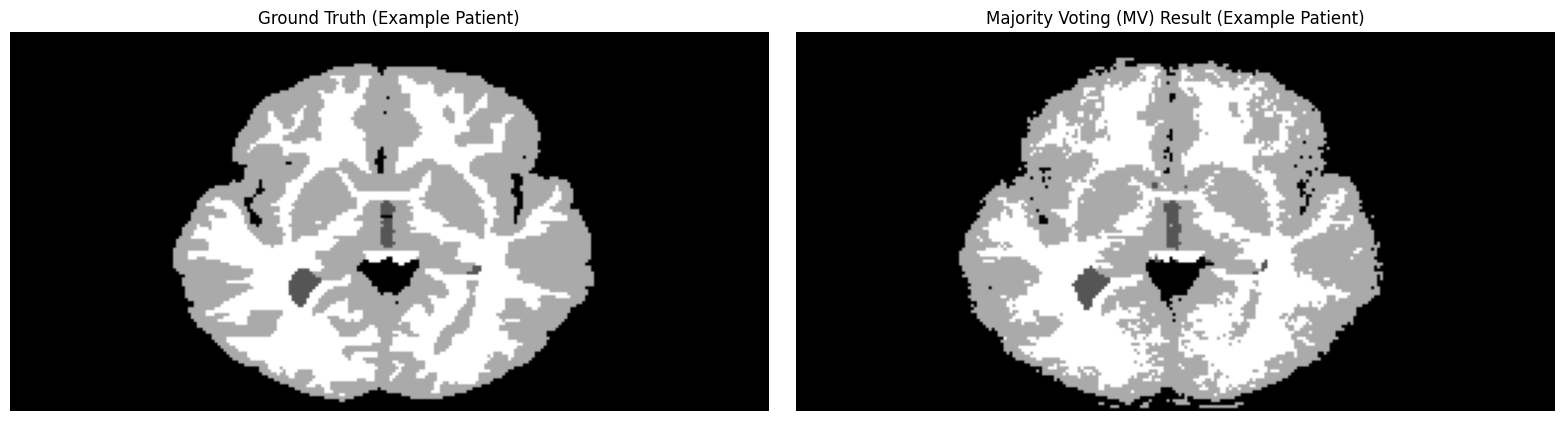

In [36]:
#  Displaying ground turth vs segmentaion result
sample_id = "IBSR_14"
ground_truth_path = os.path.join(validation_dir, sample_id, f"{sample_id}_seg.nii.gz")
segmentation_result_path = os.path.join(non_local_similar_patch_dir, f"{sample_id}_NonLocal_SimilarPatch.nii.gz")

# Load images
ground_truth = load_nifti_image(ground_truth_path)
segmentation_result = load_nifti_image(segmentation_result_path)

# Visualize the results
visualize_segmentation_results(
    ground_truth=ground_truth,
    segmentation_result=segmentation_result,
    title_suffix="Example Patient",
    method_name="Majority Voting (MV)"
)

### **Executing Non-local Segmentation with 9x9x9 Patch Size**

In [37]:
# Process with 9x9x9 patch size
process_non_local_segmentation_with_patches(
    transformed_labels_dir, validation_dir, registration_results_dir, non_local_similar_patch_dir_large_patch, patch_size=9
)

Processing non-local segmentation with patch size 9...
Processing validation subfolder: IBSR_12
Saved non-local segmentation for IBSR_12 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Non_Local_Segmentation_with_SimilarPatch_large_patch/IBSR_12_NonLocal_SimilarPatch.nii.gz
DSC for IBSR_12: CSF=0.807, GM=0.810, WM=0.806
AVD for IBSR_12: 0.121
Processing validation subfolder: IBSR_17
Saved non-local segmentation for IBSR_17 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Non_Local_Segmentation_with_SimilarPatch_large_patch/IBSR_17_NonLocal_SimilarPatch.nii.gz
DSC for IBSR_17: CSF=0.867, GM=0.859, WM=0.793
AVD for IBSR_17: 0.087
Processing validation subfolder: IBSR_14
Saved non-local segmentation for IBSR_14 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/Non_Local_Segmentation_with_SimilarPatch_large_patch/IBSR_14_NonLocal_SimilarPatch.nii.gz
DSC for

### **Visualizing Non-local Segmentation (9x9x9 Patch) Results**

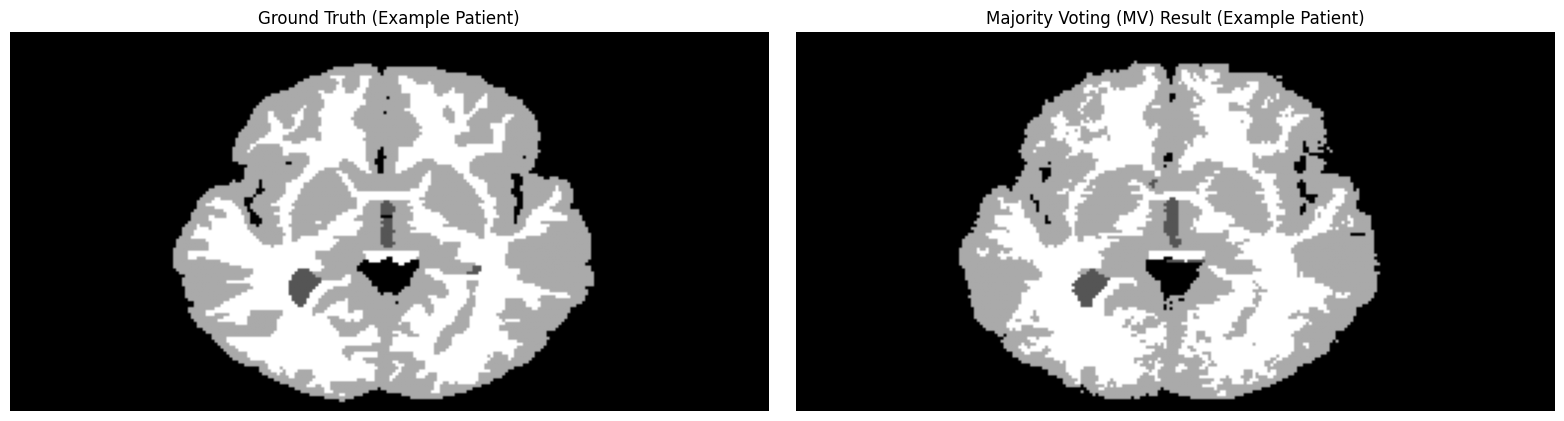

In [38]:
#  Displaying ground turth vs segmentaion result
sample_id = "IBSR_14"
ground_truth_path = os.path.join(validation_dir, sample_id, f"{sample_id}_seg.nii.gz")
segmentation_result_path = os.path.join(non_local_similar_patch_dir_large_patch, f"{sample_id}_NonLocal_SimilarPatch.nii.gz")

# Load images
ground_truth = load_nifti_image(ground_truth_path)
segmentation_result = load_nifti_image(segmentation_result_path)

# Visualize the results
visualize_segmentation_results(
    ground_truth=ground_truth,
    segmentation_result=segmentation_result,
    title_suffix="Example Patient",
    method_name="Majority Voting (MV)"
)

### **EM segmentation**

### **`min_max_scaler` Function for EM Segmentation**

In [22]:
# Function for min-max scaling
def min_max_scaler(img, max_val=255):
    img = img.astype(np.float64)
    min_val = np.min(img)
    max_img = np.max(img)
    if max_img == 0:
        return img
    return max_val * (img - min_val) / (max_img - min_val)

### **`gaussian_mixture` Function for EM Segmentation**

In [23]:

# Function to calculate Gaussian Mixture probabilities
def gaussian_mixture(data, means, std_devs, proportions):
    gmm = np.zeros((data.shape[0], len(means)))
    for k in range(len(means)):
        gmm[:, k] = proportions[k] * norm.pdf(data, means[k], std_devs[k])
    return gmm

### **Expectation-Maximization (EM) Algorithm**

In [24]:
# EM Algorithm
def em_probabilities(val_image, init_image, max_iter=20, stopping_threshold=0.05):
    val_image = min_max_scaler(val_image)
    data_1d = val_image.flatten()
    init_1d = init_image.flatten()

    # Get indices for each tissue
    indices_csf = np.where(init_1d == 1)[0]
    indices_gm = np.where(init_1d == 2)[0]
    indices_wm = np.where(init_1d == 3)[0]

    tissue_indices = np.concatenate([indices_csf, indices_gm, indices_wm])
    tissue_data = data_1d[tissue_indices]

    # Initialize GMM parameters
    clusters = [indices_csf, indices_gm, indices_wm]
    cluster_data = [data_1d[idx] for idx in clusters]
    means = [np.mean(cluster) for cluster in cluster_data]
    std_devs = [np.std(cluster) for cluster in cluster_data]
    proportions = [len(cluster) / len(tissue_data) for cluster in cluster_data]

    for iteration in range(max_iter):
        # E-Step
        gmm = gaussian_mixture(tissue_data, means, std_devs, proportions)
        sum_all_clusters = np.sum(gmm, axis=1) + 1e-8
        log_likelihood_current = np.sum(np.log(sum_all_clusters))
        responsibilities = gmm / sum_all_clusters[:, np.newaxis]

        # M-Step
        for k in range(3):  # For CSF, GM, WM
            proportions[k] = np.sum(responsibilities[:, k]) / len(tissue_data)
            means[k] = np.sum(responsibilities[:, k] * tissue_data) / np.sum(responsibilities[:, k])
            variance = np.sum(responsibilities[:, k] * (tissue_data - means[k])**2) / np.sum(responsibilities[:, k])
            std_devs[k] = np.sqrt(variance)

        # Check for convergence
        gmm = gaussian_mixture(tissue_data, means, std_devs, proportions)
        sum_all_clusters = np.sum(gmm, axis=1)
        log_likelihood_updated = np.sum(np.log(sum_all_clusters))
        if abs(log_likelihood_updated - log_likelihood_current) < stopping_threshold:
            break

    # Assign labels based on maximum probability
    _, voxel_labels = np.max(responsibilities, axis=1), np.argmax(responsibilities, axis=1)
    segmented_image = np.zeros_like(data_1d, dtype=np.int16)
    segmented_image[tissue_indices] = voxel_labels + 1  # Add 1 because labels are 1-based (CSF=1, GM=2, WM=3)

    # Reshape back to original shape
    segmented_image = segmented_image.reshape(val_image.shape)

    # Create probability maps
    prob_maps = [np.zeros_like(data_1d) for _ in range(3)]
    for idx, prob_map in enumerate(prob_maps):
        prob_map[tissue_indices] = responsibilities[:, idx]
    prob_maps = [prob_map.reshape(val_image.shape) for prob_map in prob_maps]

    return prob_maps[0], prob_maps[1], prob_maps[2], segmented_image

### **Function to Process EM Integration with Initial Segmentations**

In [25]:
# Create EM results directories if they don't exist
os.makedirs(em_results_dir, exist_ok=True)
os.makedirs(em_results_wmv_dir, exist_ok=True)
os.makedirs(em_results_non_local_dir, exist_ok=True)

# Function to process EM integration with initial segmentations
def process_em_integration(validation_dir, segmentation_dir, em_results_dir, segmentation_type):
    print(f"Processing EM integration for {segmentation_type} segmentation...")

    # Initialize lists for Dice averaging and AVD computation
    dice_scores = {"CSF": [], "GM": [], "WM": []}
    avd_scores = []

    # Iterate through validation images
    for val_subfolder in os.listdir(validation_dir):
        val_path = os.path.join(validation_dir, val_subfolder)
        if os.path.isdir(val_path):
            print(f"Processing validation subject: {val_subfolder}")

            # Load initial segmentation result
            file_suffix = {
              "Majority Voting": "_MV",
              "Weighted Majority Voting": "_WMV",
              "NonLocal_LargePatch": "_NonLocal_SimilarPatch"
            }

            if segmentation_type not in file_suffix:
              print(f"Unknown segmentation type: {segmentation_type}. Skipping.")
              continue

            segmentation_file = os.path.join(segmentation_dir, f"{val_subfolder}{file_suffix[segmentation_type]}.nii.gz")

            if not os.path.exists(segmentation_file):
              print(f"{segmentation_type} result not found for {val_subfolder}. Skipping.")
              continue

            init_segmentation = np.squeeze(nib.load(segmentation_file).get_fdata().astype(np.int16))


            # Load validation image
            validation_image_file = os.path.join(val_path, f"{val_subfolder}.nii.gz")
            validation_image = nib.load(validation_image_file).get_fdata()

            # Load ground truth
            groundtruth_file = os.path.join(val_path, f"{val_subfolder}_seg.nii.gz")
            if not os.path.exists(groundtruth_file):
                print(f"Ground truth not found for {val_subfolder}. Skipping metrics computation.")
                continue
            groundtruth = nib.load(groundtruth_file).get_fdata()

            # Apply EM algorithm
            csf_prob, gm_prob, wm_prob, segmented_image = em_probabilities(validation_image, init_segmentation)

            # Compute Dice Similarity Coefficient
            dice_csf = dice_coefficient(segmented_image == 1, groundtruth == 1)
            dice_gm = dice_coefficient(segmented_image == 2, groundtruth == 2)
            dice_wm = dice_coefficient(segmented_image == 3, groundtruth == 3)

            # Append Dice scores for averaging
            dice_scores["CSF"].append(dice_csf)
            dice_scores["GM"].append(dice_gm)
            dice_scores["WM"].append(dice_wm)

            # Compute Average Volumetric Difference (AVD)
            avd = []
            for label in [1, 2, 3]:  # Iterate over tissue labels
                gt_voxels = np.sum(groundtruth == label)
                seg_voxels = np.sum(segmented_image == label)
                avd.append(abs(gt_voxels - seg_voxels) / gt_voxels if gt_voxels > 0 else 0)
            avg_avd = np.mean(avd)

            # Append AVD score
            avd_scores.append(avg_avd)

            # Save results
            seg_output_file = os.path.join(em_results_dir, f"{val_subfolder}_EM_Segmentation.nii.gz")
            nib.save(nib.Nifti1Image(segmented_image, nib.load(validation_image_file).affine), seg_output_file)
            print(f"Saved EM segmentation for {val_subfolder} to {seg_output_file}")
            print(f"Dice Scores - CSF: {dice_csf:.3f}, GM: {dice_gm:.3f}, WM: {dice_wm:.3f}")
            print(f"AVD for {val_subfolder}: {avg_avd:.3f}")

    # Compute and print average Dice scores and AVD across all validation subjects
    avg_dice_csf = np.mean(dice_scores["CSF"]) if dice_scores["CSF"] else 0
    avg_dice_gm = np.mean(dice_scores["GM"]) if dice_scores["GM"] else 0
    avg_dice_wm = np.mean(dice_scores["WM"]) if dice_scores["WM"] else 0
    avg_avd_all = np.mean(avd_scores) if avd_scores else 0

    print(f"\nAverage Dice Scores Across All Validation Subjects for {segmentation_type}:")
    print(f"CSF: {avg_dice_csf:.3f}, GM: {avg_dice_gm:.3f}, WM: {avg_dice_wm:.3f}")
    print(f"\nAverage AVD Across All Validation Subjects for {segmentation_type}: {avg_avd_all:.3f}\n")


### **Processing EM Integration for Majority Voting (MV)**

In [26]:
# Process EM integration for Majority Voting (MV)
process_em_integration(
    validation_dir=validation_dir,
    segmentation_dir=majority_voting_dir,
    em_results_dir=em_results_dir,
    segmentation_type="Majority Voting"
)



Processing EM integration for Majority Voting segmentation...
Processing validation subject: IBSR_12
Saved EM segmentation for IBSR_12 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/EM_Results_MV/IBSR_12_EM_Segmentation.nii.gz
Dice Scores - CSF: 0.164, GM: 0.883, WM: 0.847
AVD for IBSR_12: 1.465
Processing validation subject: IBSR_17
Saved EM segmentation for IBSR_17 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/EM_Results_MV/IBSR_17_EM_Segmentation.nii.gz
Dice Scores - CSF: 0.464, GM: 0.907, WM: 0.859
AVD for IBSR_17: 0.311
Processing validation subject: IBSR_14
Saved EM segmentation for IBSR_14 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/EM_Results_MV/IBSR_14_EM_Segmentation.nii.gz
Dice Scores - CSF: 0.323, GM: 0.900, WM: 0.834
AVD for IBSR_14: 0.671
Processing validation subject: IBSR_11
Saved EM segmentation for IBSR_11 to /content/drive/M

### **Visualizing EM Segmentation Results (Majority Voting Initialization)**

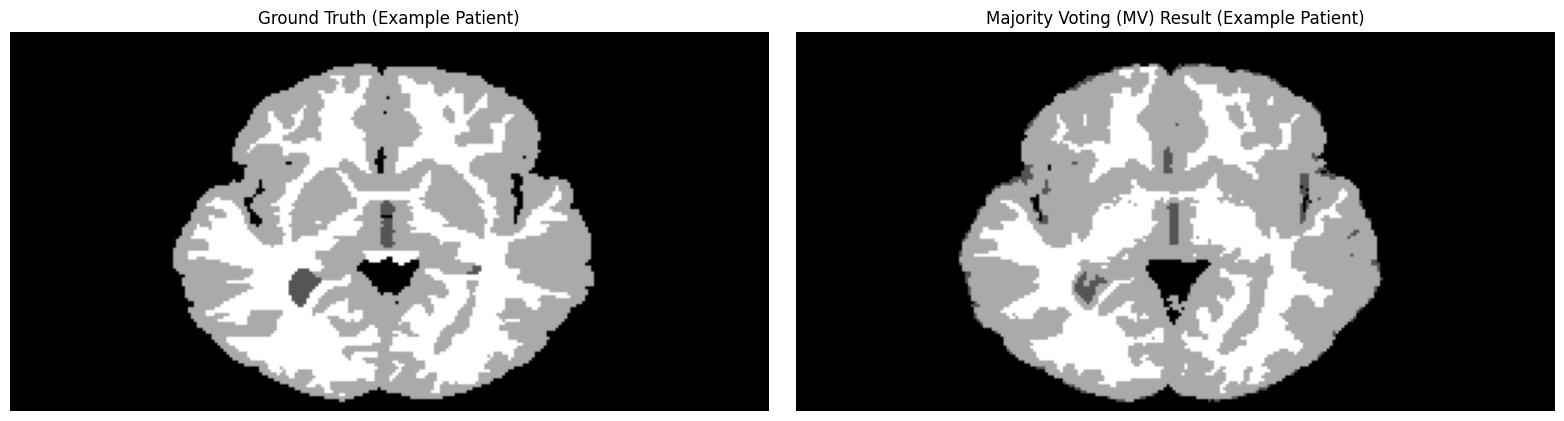

In [27]:
#  Displaying ground turth vs segmentaion result
sample_id = "IBSR_14"
ground_truth_path = os.path.join(validation_dir, sample_id, f"{sample_id}_seg.nii.gz")
segmentation_result_path = os.path.join(em_results_dir, f"{sample_id}_EM_Segmentation.nii.gz")

# Load images
ground_truth = load_nifti_image(ground_truth_path)
segmentation_result = load_nifti_image(segmentation_result_path)

# Visualize the results
visualize_segmentation_results(
    ground_truth=ground_truth,
    segmentation_result=segmentation_result,
    title_suffix="Example Patient",
    method_name="Majority Voting (MV)"
)

### **Processing EM Integration for Weighted Majority Voting (WMV)**

In [28]:
# Process EM integration for Weighted Majority Voting (WMV)
process_em_integration(
    validation_dir=validation_dir,
    segmentation_dir=weighted_majority_voting_dir,
    em_results_dir=em_results_wmv_dir,
    segmentation_type="Weighted Majority Voting"
)



Processing EM integration for Weighted Majority Voting segmentation...
Processing validation subject: IBSR_12
Saved EM segmentation for IBSR_12 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/EM_Results_WMV/IBSR_12_EM_Segmentation.nii.gz
Dice Scores - CSF: 0.155, GM: 0.889, WM: 0.867
AVD for IBSR_12: 1.565
Processing validation subject: IBSR_17
Saved EM segmentation for IBSR_17 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/EM_Results_WMV/IBSR_17_EM_Segmentation.nii.gz
Dice Scores - CSF: 0.437, GM: 0.912, WM: 0.859
AVD for IBSR_17: 0.343
Processing validation subject: IBSR_14
Saved EM segmentation for IBSR_14 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/EM_Results_WMV/IBSR_14_EM_Segmentation.nii.gz
Dice Scores - CSF: 0.296, GM: 0.907, WM: 0.853
AVD for IBSR_14: 0.760
Processing validation subject: IBSR_11
Saved EM segmentation for IBSR_11 to /con

### **Visualizing EM Segmentation Results (Weighted Majority Voting Initialization)**

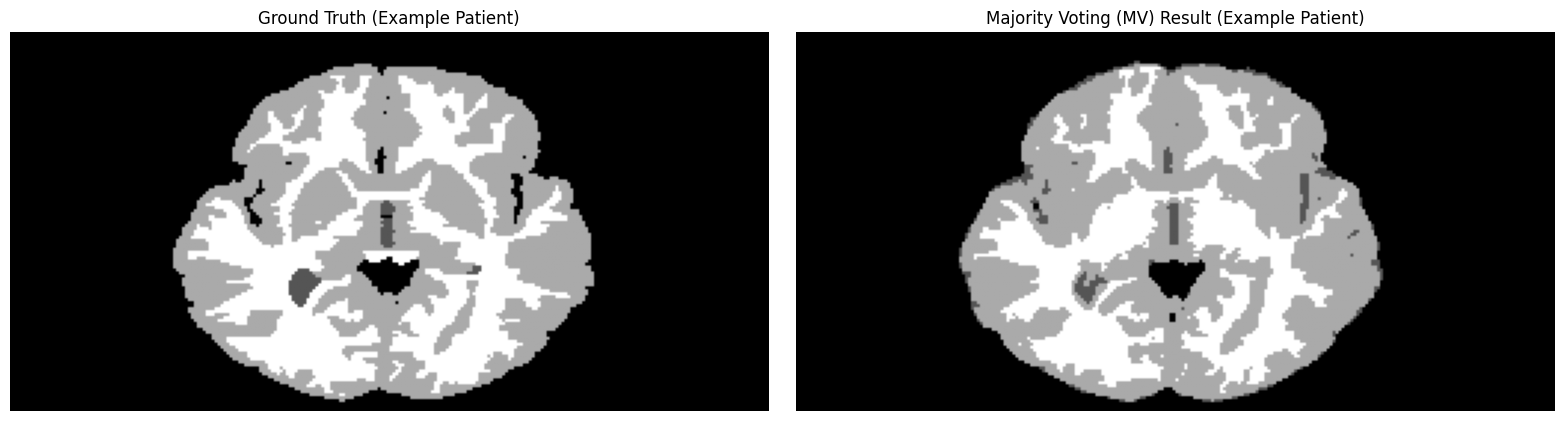

In [29]:
#  Displaying ground turth vs segmentaion result
sample_id = "IBSR_14"
ground_truth_path = os.path.join(validation_dir, sample_id, f"{sample_id}_seg.nii.gz")
segmentation_result_path = os.path.join(em_results_wmv_dir, f"{sample_id}_EM_Segmentation.nii.gz")

# Load images
ground_truth = load_nifti_image(ground_truth_path)
segmentation_result = load_nifti_image(segmentation_result_path)

# Visualize the results
visualize_segmentation_results(
    ground_truth=ground_truth,
    segmentation_result=segmentation_result,
    title_suffix="Example Patient",
    method_name="Majority Voting (MV)"
)

### **Processing EM Integration for Non-Local Means (NLM)**

In [39]:
# Process EM integration for Non-Local Means (NLM)
process_em_integration(
    validation_dir=validation_dir,
    segmentation_dir=non_local_similar_patch_dir,
    em_results_dir=em_results_non_local_dir,
    segmentation_type="NonLocal_LargePatch"
)

Processing EM integration for NonLocal_LargePatch segmentation...
Processing validation subject: IBSR_12
Saved EM segmentation for IBSR_12 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/EM_Results_NonLocal_means/IBSR_12_EM_Segmentation.nii.gz
Dice Scores - CSF: 0.214, GM: 0.880, WM: 0.867
AVD for IBSR_12: 0.944
Processing validation subject: IBSR_17
Saved EM segmentation for IBSR_17 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/EM_Results_NonLocal_means/IBSR_17_EM_Segmentation.nii.gz
Dice Scores - CSF: 0.383, GM: 0.912, WM: 0.874
AVD for IBSR_17: 0.224
Processing validation subject: IBSR_14
Saved EM segmentation for IBSR_14 to /content/drive/My Drive/Colab Notebooks/MISA/MISA_Final_Project/TrainingValidationTestSets/EM_Results_NonLocal_means/IBSR_14_EM_Segmentation.nii.gz
Dice Scores - CSF: 0.309, GM: 0.907, WM: 0.869
AVD for IBSR_14: 0.672
Processing validation subject: IBSR_11
Saved EM segm

### **Visualizing EM Segmentation Results (Non-Local Means Initialization)**

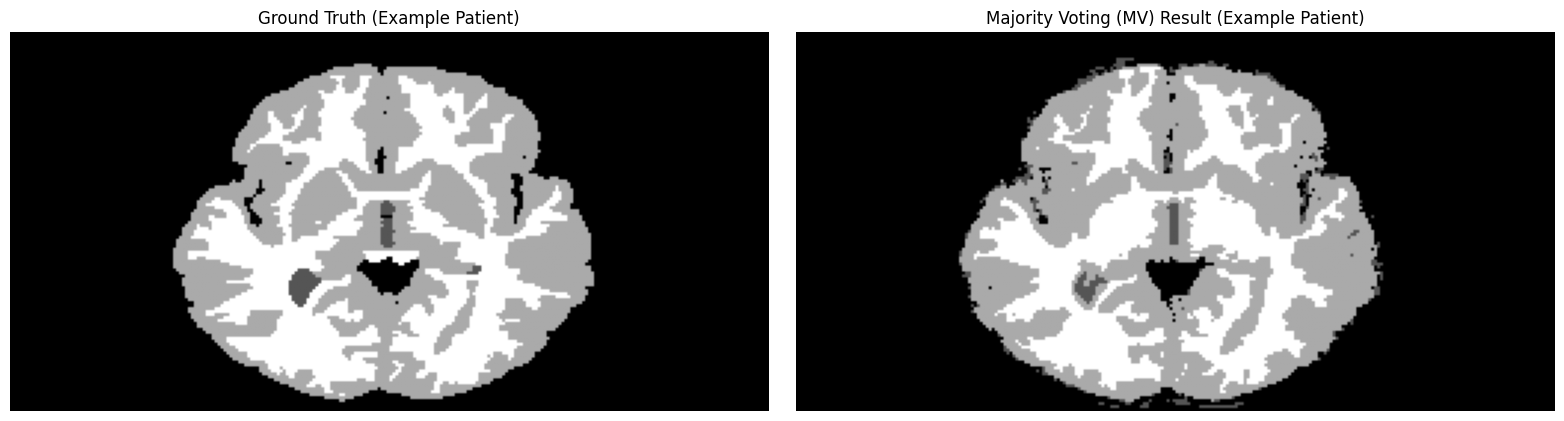

In [40]:
#  Displaying ground turth vs segmentaion result
sample_id = "IBSR_14"
ground_truth_path = os.path.join(validation_dir, sample_id, f"{sample_id}_seg.nii.gz")
segmentation_result_path = os.path.join(em_results_non_local_dir, f"{sample_id}_EM_Segmentation.nii.gz")

# Load images
ground_truth = load_nifti_image(ground_truth_path)
segmentation_result = load_nifti_image(segmentation_result_path)

# Visualize the results
visualize_segmentation_results(
    ground_truth=ground_truth,
    segmentation_result=segmentation_result,
    title_suffix="Example Patient",
    method_name="Majority Voting (MV)"
)